#Install Packages AND RESTART colab after install

In [1]:
!pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 torchaudio==2.2.0  pytorch-lightning==1.2.2  torchtext==0.6.0 -f https://download.pytorch.org/whl/torch_stable.html

!pip install scipy==1.5.4
!pip install numpy==1.26.4
!pip install tqdm
!pip install pytorch-fid==0.2.0
!pip install pandas==1.1.5
!pip install lpips==0.1.4
!pip install lmdb==1.2.1
!pip install ftfy
!pip install regex
!pip install dlib requests

Looking in links: https://download.pytorch.org/whl/torch_stable.html
  Using cached scipy-1.5.4.tar.gz (25.2 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached pandas-1.1.5.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to buil

##

## Load diffusion autoencoder checkpoitn and data

In [2]:
!gdown --id 13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8
From (redirected): https://drive.google.com/uc?id=13QHJIdS5z9fCON_iA7NWhqq8Ioah4M-8&confirm=t&uuid=dfebf68c-665f-4960-b379-9675895dd48c
To: /content/ckpts_and_data.zip
100% 4.95G/4.95G [01:36<00:00, 51.1MB/s]


In [3]:
!unzip ckpts_and_data.zip

Archive:  ckpts_and_data.zip
   creating: ckpts_and_data/
  inflating: ckpts_and_data/checkpoint_icu_bnaim.pt  
  inflating: ckpts_and_data/last.ckpt  
   creating: ckpts_and_data/cxr_images_ny/
  inflating: ckpts_and_data/cxr_images_ny/A947413.png  
  inflating: ckpts_and_data/cxr_images_ny/A922673.png  
  inflating: ckpts_and_data/cxr_images_ny/A953168.png  
  inflating: ckpts_and_data/cxr_images_ny/A925839.png  
  inflating: ckpts_and_data/cxr_images_ny/A951435.png  
  inflating: ckpts_and_data/cxr_images_ny/A963675.png  
  inflating: ckpts_and_data/cxr_images_ny/A919264.png  
  inflating: ckpts_and_data/cxr_images_ny/A978928.png  
  inflating: ckpts_and_data/cxr_images_ny/A950017.png  
  inflating: ckpts_and_data/cxr_images_ny/A974169.png  
  inflating: ckpts_and_data/cxr_images_ny/A962942.png  
  inflating: ckpts_and_data/cxr_images_ny/A997729.png  
  inflating: ckpts_and_data/cxr_images_ny/A952677.png  
  inflating: ckpts_and_data/cxr_images_ny/A948013.png  
  inflating: ckpts_an

## Load pretrained diffusion autoencoder

In [4]:
!git clone https://github.com/JanParlesak/diffae_med
!git pull https://github.com/JanParlesak/diffae_med



%cd 'diffae_med'

Cloning into 'diffae_med'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (269/269), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 558 (delta 214), reused 190 (delta 179), pack-reused 289 (from 2)
Receiving objects: 100% (558/558), 11.50 MiB | 19.86 MiB/s, done.
Resolving deltas: 100% (326/326), done.
fatal: not a git repository (or any of the parent directories): .git
/content/diffae_med


In [5]:
import os
import os.path as osp
import matplotlib.pyplot as plt

from templates import *

In [6]:
device = 'cuda'
model_config = cxr128_autoenc_130M()

print(model_config.name)


# download model weight & its inferenced latents

cxr128_autoenc_130M


In [7]:
device = 'cuda'
conf = cxr128_autoenc_130M()
# print(conf.name)
pretrained_encoder = LitModel(conf)
state = torch.load(f'/content/ckpts_and_data/last.ckpt', map_location='cpu', weights_only=False)
pretrained_encoder.load_state_dict(state['state_dict'], strict=False)
pretrained_encoder.ema_model.eval()
pretrained_encoder.ema_model.to(device);

Global seed set to 0
INFO:lightning:Global seed set to 0


Model params: 122.59 M


In [8]:
import numpy as np
from skimage import io
from torchvision.transforms.v2 import ToImage, ToDtype

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter
import math
import seaborn as sns
import imageio.v3 as imageio

In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR, StepLR
import torchvision
from torchvision import datasets, transforms, models
import fastprogress
import pandas as pd
import time

In [11]:
from PIL import Image

In [12]:
import sklearn

In [13]:
OneHotEncoder = sklearn.preprocessing.OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

## Preprocess Data

In [14]:
class CustomPipeline(Pipeline):
  """Custom sklearn Pipeline to transform data."""

  def apply_transformation(self, x):
    """Applies all transforms to the data, without applying last estimator.

    Args:
      x: Iterable data to predict on. Must fulfill input requirements of first
        step of the pipeline.

    Returns:
      xt: Transformed data.
    """
    xt = x
    for _, transform in self.steps[:-1]:
      xt = transform.fit_transform(xt)
    return xt

In [15]:
def df_summary(data):
    df = {
     'Count' : data.shape[0],
     'NA values' : data.isna().sum(),
     '% NA' : round((data.isna().sum()/data.shape[0]) * 100, 2),
     'Unique' : data.nunique(),
     'Dtype' : data.dtypes
    }
    return(pd.DataFrame(df))

In [16]:
def load_cxr_data(target_column, file_path):

  df = pd.read_csv(file_path)

  cols = ["to_patient_id", "age.splits", "gender_concept_name", "smoking_status_v","39156-5_Body mass index (BMI) [Ratio]", "htn_v", "dm_v", "ckd_v","other_lung_disease_v", "malignancies_v", "76282-3_Heart rate.beat-to-beat by EKG",
          "8480-6_Systolic blood pressure", "9279-1_Respiratory rate", "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
          "2823-3_Potassium [Moles/volume] in Serum or Plasma", "2524-7_Lactate [Moles/volume] in Serum or Plasma", "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
          "2951-2_Sodium [Moles/volume] in Serum or Plasma"] + [target_column]

  df = df[cols]

  df["smoking_status_v"] = df["smoking_status_v"].astype(str)
  df["smoking_status_v"] = np.where((df["smoking_status_v"]=='Current') | (df["smoking_status_v"]=='Former'), 1.0, 0.0)
  df["htn_v"] = df["htn_v"].astype(str)
  df["htn_v"] = np.where(df["htn_v"]=='Yes', 1.0, 0.0)
  df["dm_v"] = df["dm_v"].astype(str)
  df["dm_v"] = np.where(df["dm_v"]=='Yes', 1.0, 0.0)
  df["ckd_v"] = df["ckd_v"].astype(str)
  df["ckd_v"] = np.where(df["ckd_v"]=='Yes', 1.0, 0.0)
  df["other_lung_disease_v"] = df["other_lung_disease_v"].astype(str)
  df["other_lung_disease_v"] = np.where(df["other_lung_disease_v"]=='Yes', 1.0, 0.0)
  df["malignancies_v"] = df["malignancies_v"].astype(str)
  df["malignancies_v"] = np.where(df["malignancies_v"]=='Yes', 1.0, 0.0)

  df['39156-5_Body mass index (BMI) [Ratio]'] = df['39156-5_Body mass index (BMI) [Ratio]'].fillna(df['39156-5_Body mass index (BMI) [Ratio]'].median())
  df['76282-3_Heart rate.beat-to-beat by EKG'] = df['76282-3_Heart rate.beat-to-beat by EKG'].fillna(df['76282-3_Heart rate.beat-to-beat by EKG'].median())
  df['8480-6_Systolic blood pressure'] = df['8480-6_Systolic blood pressure'].fillna(df['8480-6_Systolic blood pressure'].median())
  df['9279-1_Respiratory rate'] = df['9279-1_Respiratory rate'].fillna(df['9279-1_Respiratory rate'].median())
  df['59408-5_Oxygen saturation in Arterial blood by Pulse oximetry'] = df['59408-5_Oxygen saturation in Arterial blood by Pulse oximetry'].fillna(df['59408-5_Oxygen saturation in Arterial blood by Pulse oximetry'].median())
  df['2823-3_Potassium [Moles/volume] in Serum or Plasma'] = df['2823-3_Potassium [Moles/volume] in Serum or Plasma'].fillna(df['2823-3_Potassium [Moles/volume] in Serum or Plasma'].median())
  df['2524-7_Lactate [Moles/volume] in Serum or Plasma'] = df['2524-7_Lactate [Moles/volume] in Serum or Plasma'].fillna(df['2524-7_Lactate [Moles/volume] in Serum or Plasma'].median())
  df['1988-5_C reactive protein [Mass/volume] in Serum or Plasma'] = df['1988-5_C reactive protein [Mass/volume] in Serum or Plasma'].fillna(df['1988-5_C reactive protein [Mass/volume] in Serum or Plasma'].median())
  df['2951-2_Sodium [Moles/volume] in Serum or Plasma'] = df['2951-2_Sodium [Moles/volume] in Serum or Plasma'].fillna(df['2951-2_Sodium [Moles/volume] in Serum or Plasma'].median())



  if target_column == "last.status":
    df[target_column] = df[target_column].astype(str)
    df[target_column] = np.where(df[target_column]== "deceased", 1.0, 0.0)

  elif target_column == "was_ventilated":
    df[target_column] = df[target_column].astype(str)
    df[target_column] = np.where(df[target_column]== "Yes", 1.0, 0.0)

  elif target_column == "is_icu":
    df[target_column] = df[target_column].astype(str)
    df[target_column] = np.where(df[target_column]== "True", 1.0, 0.0)

  df = df.dropna()

  df["gender_concept_name"] = df["gender_concept_name"].astype(str)
  df["gender_concept_name"] = np.where((df["gender_concept_name"]=='FEMALE'), 1.0, 0.0)

  return df


In [17]:
def preprocess_data(csv_file, root_dir, target_column):

  features_frame = load_cxr_data(target_column, csv_file)
  features_frame = features_frame.sample(frac=1, random_state = 1).reset_index(drop=True)

  image_dirs = []
  no_path = []

  for i in range(len(features_frame)):
    img_name = os.path.join(root_dir,
                            f'{features_frame.iloc[i, 0]}.png') # this has to be the image name in the csv

    if os.path.exists(img_name):
      image_dirs.append(img_name)

    else:
      no_path.append(i)

  features_frame = features_frame.drop(no_path)

  features_frame = features_frame.drop("to_patient_id", axis = 1)

  targets = np.array(features_frame[target_column])

  features_frame = features_frame.drop(target_column, axis = 1)

  col_min_max = {}
  x = features_frame
  for col in x:
    try:
      unique_vals = x[col].unique()
      col_min_max[col] = (np.min(unique_vals), np.max(unique_vals))
    except:
      col_min_max[col] = (0.0, 1.0)

  column_names = features_frame.columns
  new_column_names = []
  is_categorical = np.array([dt.kind == 'O' for dt in features_frame.dtypes])
  categorical_cols = features_frame.columns.values[is_categorical]
  numerical_cols = features_frame.columns.values[~is_categorical]


  for index, is_cat in enumerate(is_categorical):
    col_name = column_names[index]
    if is_cat:
      new_column_names += [
          '{}: {}'.format(col_name, val) for val in set(features_frame[col_name])
      ]
    else:
      new_column_names.append(col_name)


  cat_ohe_step = (
      'ohe',
      OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
  )

  cat_pipe = Pipeline([cat_ohe_step])
  num_pipe = Pipeline([('identity', FunctionTransformer(validate=True))])
  transformers = [('cat', cat_pipe, categorical_cols),
                  ('num', num_pipe, numerical_cols)]
  column_transform = ColumnTransformer(transformers=transformers)

  pipe = CustomPipeline([('column_transform', column_transform),
                         ('min_max', MinMaxScaler((-1, 1))), ('dummy', None)])
  df = pipe.apply_transformation(features_frame)


  return image_dirs, df.astype('float32'), targets.astype('float32'), col_min_max, new_column_names

In [18]:
imgs_dir, features, targets, col_min_max, new_col_names = preprocess_data(csv_file = '/content/ckpts_and_data/patient_data.csv', root_dir= '/content/ckpts_and_data/cxr_images_ny',
                          target_column= 'is_icu')

In [19]:
transforms_train = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.RandomRotation(degrees = (-15, 15)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    #torchvision.transforms.CenterCrop(image_size)
])

transforms_val_test = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [20]:
def oversampling(dataset, targets, batch_size):

  unique, counts = np.unique(targets, return_counts=True)
  class_weights = [1.0/c for c in counts]
  sample_weights = [class_weights[int(i)] for i in targets]
  sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

  return torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)

In [21]:
class CustomDataset_img_features(torch.utils.data.Dataset):
    """Face Landmarks dataset."""
    def __init__(self, img_dirs, feature_ten, label_ten, transforms=None):

        self.img_dirs = img_dirs
        self.label_ten = label_ten
        self.feature_ten = feature_ten
        self.transforms = transforms

        assert len(img_dirs) == len(label_ten) ==  len(feature_ten), "img_ten and and feature_ten and label ten must have equal size"
    def __len__(self):
      return len(self.img_dirs)

    def __getitem__(self, idx):
      img_name = self.img_dirs[idx]
      image = Image.open(img_name).convert('RGB')
      feat = self.feature_ten[idx]
      y = self.label_ten[idx]

      if self.transforms:
        image = self.transforms(image)

      return image, feat, y

    def set_transforms(self, transforms):
      self.transforms = transforms

In [22]:
def train_test_split_features_images(features, image_dir, targets, train_frac, val_frac, batch_size, transforms_val_test = None, transforms_train = None):
    tot_len = len(features)

    train_max_idx = int(tot_len*train_frac)
    val_max_idx = int(tot_len*val_frac) + train_max_idx

    train_features = features[:train_max_idx]
    train_images = image_dir[:train_max_idx]
    train_y = targets[:train_max_idx]

    val_features = features[train_max_idx:val_max_idx]
    val_images = image_dir[train_max_idx:val_max_idx]
    val_y = targets[train_max_idx:val_max_idx]

    test_features = features[val_max_idx:]
    test_images = image_dir[val_max_idx:]
    test_y = targets[val_max_idx:]

    train_set = CustomDataset_img_features(train_images, train_features, train_y, transforms = transforms_train)
    val_set = CustomDataset_img_features(val_images, val_features, val_y, transforms = transforms_val_test)
    test_set = CustomDataset_img_features(test_images, test_features, test_y, transforms = transforms_val_test)

    train_loader = oversampling(train_set, batch_size = batch_size, targets = train_y)
    #train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size)

    return train_loader, val_loader, test_loader

In [23]:
train_loader_img, val_loader_img, test_loader_img = train_test_split_features_images(image_dir = imgs_dir,
                                                         features = torch.tensor(features),
                                                         targets = torch.tensor(targets),
                                                         train_frac = 0.7,
                                                         val_frac = 0.2,
                                                         batch_size = 16,
                                                         transforms_val_test = transforms_val_test,
                                                         transforms_train = transforms_train)

In [24]:
def plot_function(x1,x2):
    width =0.3
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    plt.bar(np.arange(1, len(x1)+1), x1, width=width)
    plt.bar(np.arange(1, len(x2)+1)+ width, x2, width=width)
    ax.legend(labels=['Class 0', 'Class 1'])
    plt.show()

zeros = []
ones = []

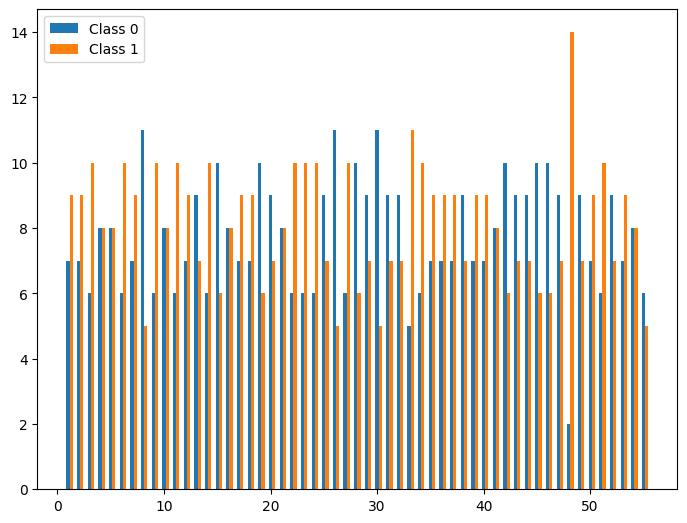

In [25]:
zeros = []
ones = []
for idx, (i,x,y) in enumerate(train_loader_img):
    unique, counts = np.unique(y.numpy(), return_counts=True)
    zeros.append(counts[0])
    ones.append(counts[1])

plot_function(zeros,ones)

## Define Models

In [26]:
import sklearn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    auc,
    precision_recall_curve,
    roc_curve,
    average_precision_score, # Import the rest of the metrics
)

In [27]:
class BayesLinear(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 bias = True,
                 weight_prior_mu = 0,
                 weight_prior_sigma = 0.1,
                 bias_prior_mu = 0,
                 bias_prior_sigma = 1.):

        super(BayesLinear, self).__init__()

        self.samples = {'weights' : None, 'bias' : None}

        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias
        self.weight_prior_mu = weight_prior_mu
        self.weight_prior_sigma = weight_prior_sigma
        self.l_weight_prior_sigma = torch.log(torch.tensor(weight_prior_sigma)) # take log of the sigma prior

        self.weights_mu = Parameter(torch.rand(out_features, in_features)-0.5) #initialize mu weights
        self.lweights_sigma = Parameter(torch.log(weight_prior_sigma*torch.ones(out_features, in_features))) # intialize log weights for sigma

        if self.bias:
            self.bias_prior_mu = bias_prior_mu
            self.bias_prior_sigma = bias_prior_sigma
            self.bias_mean = Parameter(torch.rand(out_features)-0.5) # intialize bias mean if given
            self.lbias_sigma = Parameter(torch.log(bias_prior_sigma* torch.ones(out_features))) # intialize bias sigma



    def getSampledWeights(self):
        return self.samples['weights']

    def getSampledBias(self):
        return self.samples['bias']

    def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()


    def forward(self, x):


        self.samples['weights'] = self.weights_mu + torch.exp(self.lweights_sigma) * torch.randn_like(self.lweights_sigma) #training with stochastic gradient ascent

        kl = self.kl_div(self.weights_mu, self.lweights_sigma, self.weight_prior_mu, self.l_weight_prior_sigma)

        if self.bias:

          self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
          kl += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


        out = F.linear(x, self.samples['weights'], self.samples['bias'] if self.bias else None) # return linear


        return out, kl

In [28]:
class BayesFeature(nn.Module):
  def __init__(self, hid_dim=[], dropout_rate = 0.0, prior_scale= .1, activation_function = nn.LeakyReLU()):
    super(BayesFeature, self).__init__()

    self.activation = activation_function

    self.layer_sizes = [1] + hid_dim + [1]

    self.layers = nn.ModuleList([
        BayesLinear(self.layer_sizes[idx - 1], self.layer_sizes[idx], weight_prior_sigma = prior_scale) for idx in
                      range(1, len(self.layer_sizes))])

    self.dropout = torch.nn.Dropout(p = dropout_rate)

  def forward(self, x):

    kl_sum = 0
    out, kl = self.layers[0](x)
    kl_sum += kl
    out = self.activation(out)

    for layer in self.layers[1:-1]:
      out, kl = layer(out)
      kl_sum += kl
      out = self.activation(out)
      out = self.dropout(out)

    out, kl = self.layers[-1](out)
    kl_sum += kl


    return out, kl_sum

class BayesNAM(nn.Module):
  def __init__(self,
                n_features,   # number of neurons in first layer
                hidden_units = [],  # tuple of numbers of hidden units
                dropout_rate = 0.0,
                feature_dropout_rate = 0.0,
                activation = nn.LeakyReLU(),
                prior_scale = .1,
                return_output_lis = False
                ):
      super().__init__()


      self.samples = {'bias' : None}

      #self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.feature_dropout_rate = feature_dropout_rate

      self.feature_dropout = torch.nn.Dropout(p=self.feature_dropout_rate)

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
          BayesFeature(hid_dim = hidden_units, dropout_rate= dropout_rate, prior_scale= prior_scale, activation_function = activation)
          for i in range(n_features)
      ])

      self.bias = nn.Parameter(torch.zeros(1))

      self.bias_prior_mu = 0.
      self.bias_prior_sigma = .1
      self.bias_mean = Parameter(torch.rand(1) -0.5) # intialize bias mean if given
      self.lbias_sigma = Parameter(torch.log(prior_scale* torch.ones(1)))


  def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()

  def getSampledBias(self):
        return self.samples['bias']


  def forward(self, f):

    #eta = self.bias
    output_lis = []
    kl_total = 0

    for feature, mod in zip(f.T, self.feature_nns):

      feature = feature.unsqueeze(-1)
      ri, kl = mod(feature)
      kl_total += kl
      output_lis.append(ri)


    self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
    kl_total += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)

    if self.return_output_lis:
      return output_lis, kl_total

    else:
      conc_out = torch.cat(output_lis, dim=-1)
      dropout_out = self.feature_dropout(conc_out)
      out = torch.sum(dropout_out, dim=-1) + self.bias  #+ self.samples['bias'] #

      #out = out_1 + out_2 + out_3 + self.bias

      return out, kl_total


class BayesSkipBlock(nn.Module):
  def __init__(self, in_features, out_features, prior_scale = 0.1):
    super(BayesSkipBlock, self).__init__()


    self.linear_in = BayesLinear(in_features = in_features, out_features = in_features, weight_prior_sigma = prior_scale)
    self.linear_out = BayesLinear(in_features = in_features, out_features = in_features, weight_prior_sigma = prior_scale)

    self.act = torch.nn.LeakyReLU()

    self.bn1 = nn.BatchNorm1d(in_features, affine = True) # needs to be adjusted
    self.bn2 = nn.BatchNorm1d(out_features, affine = True)


  def forward(self, x):

    kl_sum = 0
    x0 = x

    x, kl = self.linear_in(x)
    kl_sum += kl
    x = self.bn1(x)
    x = self.act(x)

    x, kl = self.linear_out(x)
    kl_sum += kl
    x = self.bn2(x)

    x = x0 + x

    x = self.act(x)

    return x, kl_sum




class BayesResFeature(nn.Module):
  def __init__(self, n_input, hid_dim, dropout_rate = 0.0, prior_scale= .1, activation_function = nn.LeakyReLU()):
    super(BayesResFeature, self).__init__()

    self.activation = activation_function

    self.input_layer = BayesLinear(n_input, hid_dim[0])

    self.layers = nn.ModuleList([
        BayesSkipBlock(hid_dim[0], hid_dim[0], prior_scale = prior_scale) for idx in
                      range(1, len(hid_dim))])

    self.output_layer = BayesLinear(hid_dim[0], 1)

    self.dropout = torch.nn.Dropout(p = dropout_rate)

    self.bn1 = nn.BatchNorm1d(hid_dim[0], affine = True)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.input_layer(x)
    kl_sum += kl
    #out = self.bn1(out)
    out = self.activation(out)
    out = self.dropout(out)

    for layer in self.layers:
      out, kl = layer(out)
      kl_sum += kl

    out, kl = self.output_layer(out)
    kl_sum += kl

    return out, kl_sum


class BayesRes(nn.Module):
  def __init__(self,
                n_features,   # number of neurons in first layer
                hidden_units = [50,100,100,50],  # tuple of numbers of hidden units
                dropout_rate = 0.0,
                feature_dropout_rate = 0.0,
                activation = nn.LeakyReLU(),
                prior_scale = .1,
                return_output_lis = False
                ):
      super().__init__()


      self.samples = {'bias' : None}

      #self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.feature_dropout_rate = feature_dropout_rate

      self.feature_dropout = torch.nn.Dropout(p=self.feature_dropout_rate)

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
          BayesResFeature(hid_dim = hidden_units, dropout_rate= dropout_rate, prior_scale= prior_scale, activation_function = activation)
          for i in range(n_features)
      ])

      self.bias = nn.Parameter(torch.zeros(1))

      self.bias_prior_mu = 0.
      self.bias_prior_sigma = .1
      self.bias_mean = Parameter(torch.rand(1) -0.5) # intialize bias mean if given
      self.lbias_sigma = Parameter(torch.log(prior_scale* torch.ones(1)))


  def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()

  def getSampledBias(self):
        return self.samples['bias']


  def forward(self, f):

    #eta = self.bias
    output_lis = []
    kl_total = 0

    for feature, mod in zip(f.T, self.feature_nns):

      feature = feature.unsqueeze(-1)
      ri, kl = mod(feature)
      kl_total += kl
      output_lis.append(ri)

    #self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
    #kl_total += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


    conc_out = torch.cat(output_lis, dim=-1)
    dropout_out = self.feature_dropout(conc_out)
    out = torch.sum(dropout_out, dim=-1) + self.bias #+ self.samples['bias']


    return out, kl_total

class BayesImageNAM(torch.nn.Module):
  def __init__(self,
                pretrained_encoder,
                bayes_mlp, #BayesResFeature
                bayes_feat_nam,
                ):
      super().__init__()

      self.pretrained_encoder = pretrained_encoder
      self.bayes_mlp = bayes_mlp
      self.bayes_feat_nam = bayes_feat_nam
      self.bayes_feat_nam.return_output_lis = True

  def forward(self, image, features):

    total_kl = 0

    output_lis_nam, kl = self.bayes_feat_nam(features)

    total_kl += kl

    res_cnn = self.pretrained_encoder.encode(image)
    res_cnn, kl = self.bayes_mlp(res_cnn)

    total_kl += kl

    output_lis = output_lis_nam + [res_cnn]
    output_lis = torch.cat(output_lis, dim=-1)

    output_lis = self.bayes_feat_nam.feature_dropout(output_lis)
    out = torch.sum(output_lis, dim=-1) + self.bayes_feat_nam.bias
    return out, total_kl

## Run Training

In [29]:
n_features = features.shape[-1]
hidden_units = [100, 100, 100] # [50, 50, 50, 50] (100, 100, 100)
dropout_rate= 0.2  #[0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,0.8, 0.9],
feature_dropout_rate= 0.5 # [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
prior_scale=0.1

In [30]:
bayes_mlp = BayesResFeature(n_input = 512, hid_dim = [500,500,500,500])
bayes_nam = BayesNAM(n_features = n_features, hidden_units = hidden_units, dropout_rate = dropout_rate, feature_dropout_rate = feature_dropout_rate,
                        prior_scale = prior_scale)
model = BayesImageNAM(pretrained_encoder = pretrained_encoder, bayes_mlp = bayes_mlp, bayes_feat_nam = bayes_nam)

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-3)

In [32]:
def var_exp_score(predictions, targets):
  mean_sum_of_squares = torch.mean((predictions - targets)**2)
  variance_targets = torch.var(targets)
  var_exp = 1- mean_sum_of_squares/variance_targets

  return var_exp

def coef_det(x, y):
  sum_x = torch.sum(x)
  sum_y = torch.sum(y)
  n = len(x)

  numerator = n * torch.sum(x * y) - sum_x*sum_x
  denominator = (n * torch.sum(x**2) - sum_x**2)**0.5 * (n * torch.sum(y**2) - sum_y**2)**0.5

  return numerator/denominator


def mad_explained(predictions, targets):
  mean_sum_of_ad = torch.mean(torch.abs(predictions - targets))
  deviation_median = torch.mean(torch.abs(targets - torch.median(targets)))

  mad_exp = 1 - mean_sum_of_ad/deviation_median

  return mad_exp

In [33]:
def validate_images(model, device, mode, val_loader, loss_fun, kl_weight, batch_size, n_samples):

    val_loss = []

    target_lis = []
    pred_lis = []
    norm_pred = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):

            images, features, target = batch

            images = images.to(device)
            target = target.to(device)
            features = features.to(device)

            output = []
            kl_div = []


            for sample in range(n_samples):
                out, kl = model(images, features)
                output.append(out)
                kl_div.append(kl)

            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            mean_pred = mean_pred.squeeze(-1)
            log_lik_loss = loss_fun(mean_pred, target)

            scaled_kl = kl_loss * kl_weight / batch_size

            loss = log_lik_loss + scaled_kl
            val_loss.append(loss.cpu())

            target_lis.append(target.detach().cpu())
            norm_pred.append(torch.sigmoid(mean_pred).detach().cpu())


            pred_lis.append(torch.round(torch.sigmoid(mean_pred)).detach().cpu() if mode == "classification" else
                            mean_pred.detach().cpu())

        mean_loss = np.mean(np.array(val_loss))

        target_ten, pred_ten = torch.cat(target_lis), torch.cat(pred_lis)
        norm_pred_lis = torch.cat(norm_pred)


        if mode == "classification":
          pre, re, thresholds = precision_recall_curve(target_ten, norm_pred_lis) #other paper uses roc_curve here
          auc_precision_recall = auc(re, pre)

          pre_2, re_2, thresholds_2 = roc_curve(target_ten, norm_pred_lis)
          auc_val = auc(pre_2, re_2)

          balanced_acc = balanced_accuracy_score(target_ten, pred_ten)
          recall = recall_score(target_ten, pred_ten)
          precision = precision_score(target_ten, pred_ten)


          return mean_loss, auc_precision_recall, auc_val, balanced_acc, recall, precision
        else:
           var_exp = var_exp_score(pred_ten, target_ten)
           mad_exp = mad_explained(pred_ten, target_ten)
           r_score = coef_det(pred_ten, target_ten)

           return mean_loss, var_exp, mad_exp, r_score





def train_images(model, optimizer, loss_fun, trainset, valset, device, n_epochs, n_samples, mode, batch_size = 256, kl_weight = 0.1, early_stopping = True, n_epochs_early_stopping = 50, save_path = None, print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []


    if early_stopping == True:
      n_early_stopping = n_epochs_early_stopping
      past_val_losses = []
      pr_auc_lis = []

    model = model.to(device)
    model.train()

    for epoch in range(n_epochs):
        target_lis = []
        pred_lis = []
        start = time.time()
        for i, batch in enumerate(tqdm(trainset)):

            images, features, target = batch

            images = images.to(device)
            target = target.to(device)
            features = features.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):
                out, kl = model(images, features)
                output.append(out)
                kl_div.append(kl)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            mean_pred = mean_pred.squeeze(-1)

            loss = loss_fun(mean_pred, target)
            scaled_kl = kl_loss * kl_weight / batch_size
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())
            target_lis.append(target.detach().cpu())
            pred_lis.append(torch.round(torch.sigmoid(mean_pred)).detach().cpu() if mode == "classification" else
                            mean_pred.detach().cpu())

        if epoch % print_mod == 0:

            end = time.time()
            time_delta = end - start

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss.append(mean_loss)
            loss_lis = []

            target_ten, pred_ten = torch.cat(target_lis), torch.cat(pred_lis)

            if mode == "classification":
              acc = accuracy_score(target_ten, pred_ten)
              recall = recall_score(target_ten, pred_ten)
              precision = precision_score(target_ten, pred_ten)
              f1 = f1_score(target_ten, pred_ten)

              mean_loss_val, pr_auc_val, auc_val, balanced_acc_val, recall_val, precision_val = validate_images(model = model, device = device, mode = mode,
                                              val_loader = valset, loss_fun = loss_fun, kl_weight = kl_weight, batch_size = batch_size, n_samples = n_samples)
              val_loss.append(mean_loss_val)

              print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss},  train_acc = {acc}, train_recall = {recall}, train_precision = {precision}, train_f1 = {f1}, elapsed time: {time_delta}')
              print(f'Epoch nr {epoch}: mean_valid_loss = {mean_loss_val}, PR AUC = {pr_auc_val}, AUC = {auc_val}, Balanced Accuracy = {balanced_acc_val}, val_recall = {recall_val}, val_precision = {precision_val}')

              if early_stopping:

                if len(pr_auc_lis) == 0 or pr_auc_val > max(pr_auc_lis):
                  print("save model")
                  torch.save(model.state_dict(), save_path)

                if len(pr_auc_lis) >= n_early_stopping:
                  if pr_auc_val < min(pr_auc_lis):
                    print(f"Early stopping because the AUC has not increased since the last {n_early_stopping} epochs")
                    return overall_loss, val_loss
                  else:
                    pr_auc_lis = pr_auc_lis[1:] + [pr_auc_val]
                else:
                  pr_auc_lis = pr_auc_lis + [pr_auc_val]



            elif mode == "regression":

              var_exp = var_exp_score(pred_ten, target_ten)
              mad_exp = mad_explained(pred_ten, target_ten)
              r_score = coef_det(pred_ten, target_ten)

              mean_loss_val, var_exp_val, mad_exp_val, r_score_val = validate_images(model = model, device = device, mode = mode,
                                                val_loader = valset, loss_fun = loss_fun, kl_weight = kl_weight, batch_size = batch_size, n_samples = n_samples)

              val_loss.append(mean_loss_val)

              print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}, train_acc = {var_exp}, train_recall = {mad_exp}, train_precision = {r_score}, elapsed time: {time_delta}')
              print(f'Epoch nr {epoch}: mean_valid_loss = {mean_loss_val}, val_accuracy = {var_exp_val}, val_recall = {mad_exp_val}, val_precision = {r_score_val}')


              if early_stopping:

                if len(past_val_losses) == 0 or mean_loss_val < min(past_val_losses):
                  print("save model")
                  torch.save(model.state_dict(), save_path)

                if len(past_val_losses) >= n_early_stopping:
                  if mean_loss_val > max(past_val_losses):
                    print(f"Early stopping because the median validation loss has not decreased since the last {n_early_stopping} epochs")
                    return overall_loss, val_loss
                  else:
                    past_val_losses = past_val_losses[1:] + [mean_loss_val]
                else:
                  past_val_losses = past_val_losses + [mean_loss_val]

    return overall_loss, val_loss


In [34]:
model_save_name_one = ''
path_one = '/content/bnaim_icu_checkpoint.pt'

In [35]:
loss_train, loss_val = train_images(model = model,
           optimizer = optimizer,
           loss_fun = F.binary_cross_entropy_with_logits,     #try again with -1 1 labels and hinge loss
           trainset = train_loader_img,
           valset = val_loader_img,
           device = device,
           n_epochs = 120,
           n_samples = 1,
           mode = "classification",
           batch_size = 16,
           kl_weight = 0.01,
           early_stopping = True,
           n_epochs_early_stopping = 50,
           save_path = path_one,
           print_mod = 10)

  0%|          | 0/55 [00:00<?, ?it/s]

Epoch nr 0: mean_train_loss = 31.743558883666992,  train_acc = 0.5474285714285714, train_recall = 0.5253456221198156, train_precision = 0.5454545454545454, train_f1 = 0.5352112676056338, elapsed time: 8.992105484008789
Epoch nr 0: mean_valid_loss = 32.7169303894043, PR AUC = 0.6012674922844587, AUC = 0.634182549564218, Balanced Accuracy = 0.5771956709127478, val_recall = 0.9056603773584906, val_precision = 0.24489795918367346
save model


  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

...

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

In [36]:
torch.save(model.state_dict(), path_one)

In [37]:
model.load_state_dict(torch.load(path_one))

<All keys matched successfully>

In [38]:
def get_test_predictions(model, test_loader, n_samples, mode):

    target_lis = []
    pred_lis = []
    norm_pred = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(test_loader):

            images, features, target = batch

            images = images.to(device)
            target = target.to(device)
            features = features.to(device)

            output = []

            for sample in range(n_samples):
                out, _ = model(images, features)
                output.append(out)

            mean_pred = torch.mean(torch.stack(output), dim = 0)

            #mean_pred = mean_pred.squeeze(-1)

            norm_pred.append(torch.sigmoid(mean_pred).detach().cpu())

            target_lis.append(target.detach().cpu())

            pred_lis.append(torch.round(torch.sigmoid(mean_pred)).detach().cpu() if mode == "classification" else
                            mean_pred.detach().cpu())

        target_ten, pred_ten, norm_pred_lis = torch.cat(target_lis), torch.cat(pred_lis), torch.cat(norm_pred)

        if mode == "classification":
          pre, re, thresholds = precision_recall_curve(target_ten, norm_pred_lis) #other paper uses roc_curve here
          auc_precision_recall = auc(re, pre)

          pre_2, re_2, thresholds_2 = roc_curve(target_ten, norm_pred_lis)
          auc_val = auc(pre_2, re_2)

          balanced_acc = balanced_accuracy_score(target_ten, pred_ten)
          recall = recall_score(target_ten, pred_ten)
          precision = precision_score(target_ten, pred_ten)


          return auc_precision_recall, auc_val, balanced_acc, recall, precision
        else:
           var_exp = var_exp_score(pred_ten, target_ten)
           mad_exp = mad_explained(pred_ten, target_ten)
           r_score = coef_det(pred_ten, target_ten)

           return var_exp, mad_exp, r_score


In [39]:
auc_pr_test, auc_test, balanced_acc_test, recall_test, precision_test = get_test_predictions(model, test_loader_img, n_samples=100, mode = "classification")


print(f'AUC_PR: {auc_pr_test}, AUC: {auc_test}, Balanced Accuracy: {balanced_acc_test}, Recall: {recall_test}, Precision: {precision_test}')

AUC_PR: 0.6784835780108964, AUC: 0.8728897715988083, Balanced Accuracy: 0.7922045680238332, Recall: 0.631578947368421, Precision: 0.7058823529411765
